# Percentile Analysis — P95/P99 Tail Latency Focus

Head-to-head comparison of **Genesys Notifications API (WebSocket)**, **EventBridge (SQS)**, and **Deepgram Nova-3 (AudioHook proxy)** using **p95 and p99 as primary metrics**.

In production systems, mean and median obscure the experience of the worst-served users. This notebook uses percentile-based analysis throughout:
- **p95**: 1 in 20 utterances exceeds this latency
- **p99**: 1 in 100 utterances exceeds this latency

At 40,000 calls/day with ~20 utterances each, p95 affects **~40,000 utterances/day** and p99 affects **~8,000 utterances/day**.

## Formula

```
true_latency = receivedAt - deepgram_audio_wall_clock_end
```

Same methodology as `cross_system_latency-02-EB-RESULTS.ipynb` — see that notebook for full method documentation.

---
## Module 1: Setup & Configuration

In [1]:
import json
import statistics
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from scripts.correlate_latency import (
    correlate,
    correlate_eventbridge,
    export_csv,
    load_deepgram_session,
    load_genesys_conversation,
    load_eventbridge_conversation,
    match_utterances,
    compute_latency,
    CorrelationResult,
)

# === DIRECTORIES ===
DEEPGRAM_RESULTS_DIR = (REPO_ROOT / ".." / "poc-deepgram" / "results").resolve()
NOTIF_EVENTS_DIR = (REPO_ROOT / "conversation_events").resolve()
EB_EVENTS_DIR = (REPO_ROOT / "EventBridge" / "conversation_events").resolve()

OUTPUT_DIR = REPO_ROOT / "analysis_results" / "cross_system_eb_p99"
SAVE_DPI = 300
SIMILARITY_THRESHOLD = 0.70
NUM_RECENT = 6

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root: {REPO_ROOT}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Deepgram results: {DEEPGRAM_RESULTS_DIR}")
print(f"Notifications events: {NOTIF_EVENTS_DIR}")
print(f"EventBridge events: {EB_EVENTS_DIR}")

Repo root: /Users/xnxn040/PycharmProjects/notifications-spike
Output dir: /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system_eb_p99
Deepgram results: /Users/xnxn040/PycharmProjects/poc-deepgram/results
Notifications events: /Users/xnxn040/PycharmProjects/notifications-spike/conversation_events
EventBridge events: /Users/xnxn040/PycharmProjects/notifications-spike/EventBridge/conversation_events


---
## Module 2: Load & Auto-Match Files

In [2]:
dg_files = sorted(DEEPGRAM_RESULTS_DIR.glob("*.json"), key=lambda f: f.stat().st_mtime, reverse=True)
notif_files = sorted(NOTIF_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)
eb_files = sorted(EB_EVENTS_DIR.glob("*.jsonl"), key=lambda f: f.stat().st_mtime, reverse=True)

print(f"Available: {len(dg_files)} Deepgram, {len(notif_files)} Notifications, {len(eb_files)} EventBridge")


def get_dg_time_range(path):
    data = json.loads(path.read_text())
    session = data.get("session", {})
    started = session.get("started_at", "")
    ended = session.get("ended_at", "")
    start_ts = datetime.fromisoformat(started).timestamp() if started else 0
    end_ts = datetime.fromisoformat(ended).timestamp() if ended else float("inf")
    return start_ts, end_ts


def get_jsonl_time_range(path):
    lines = path.read_text().strip().splitlines()
    if not lines:
        return 0, 0
    timestamps = [json.loads(line)["receivedAt"] for line in lines]
    return min(timestamps), max(timestamps)


dg_recent = dg_files[:NUM_RECENT]
notif_recent = notif_files[:NUM_RECENT]
eb_recent = eb_files[:NUM_RECENT]

# Match Deepgram <-> Notifications by time overlap
notif_matched = []
used_notif = set()
for dg_path in dg_recent:
    dg_start, dg_end = get_dg_time_range(dg_path)
    best_idx, best_overlap = None, 0
    for j, nf in enumerate(notif_recent):
        if j in used_notif:
            continue
        nf_start, nf_end = get_jsonl_time_range(nf)
        overlap = max(0, min(dg_end, nf_end) - max(dg_start, nf_start))
        if overlap > best_overlap:
            best_overlap = overlap
            best_idx = j
    if best_idx is not None:
        notif_matched.append((dg_path, notif_recent[best_idx]))
        used_notif.add(best_idx)

# Match Notifications <-> EventBridge by conversation ID
eb_by_conv_id = {f.stem: f for f in eb_recent}

triple_matched = []
for dg_path, notif_path in notif_matched:
    conv_id = notif_path.stem
    eb_path = eb_by_conv_id.get(conv_id)
    triple_matched.append((dg_path, notif_path, eb_path))

# EB-only pairs
triple_eb_stems = {eb_p.stem for _, _, eb_p in triple_matched if eb_p}
eb_only_matched = []
used_dg_for_eb_only = set()
for eb_path in eb_recent:
    if eb_path.stem in triple_eb_stems:
        continue
    eb_start, eb_end = get_jsonl_time_range(eb_path)
    best_dg, best_overlap = None, 0
    for dg_path in dg_recent:
        if dg_path in used_dg_for_eb_only:
            continue
        dg_start, dg_end = get_dg_time_range(dg_path)
        overlap = max(0, min(dg_end, eb_end) - max(dg_start, eb_start))
        if overlap > best_overlap:
            best_overlap = overlap
            best_dg = dg_path
    if best_dg is not None:
        eb_only_matched.append((best_dg, eb_path))
        used_dg_for_eb_only.add(best_dg)

print(f"Matched {len(triple_matched)} session triple(s), {len(eb_only_matched)} EB-only pair(s)")

Available: 6 Deepgram, 6 Notifications, 6 EventBridge
Matched 6 session triple(s), 0 EB-only pair(s)


---
## Module 3: Correlate All Paths with Deepgram Ground Truth

In [3]:
# Correlate Notifications path
notif_results = []
for dg_path, nf_path, eb_path in triple_matched:
    pair_results = correlate(dg_path, nf_path, similarity_threshold=SIMILARITY_THRESHOLD)
    notif_results.extend(pair_results)
    print(f"  {dg_path.name} <-> {nf_path.name}: {len(pair_results)} matched")

# Correlate EventBridge path
eb_results = []
for dg_path, nf_path, eb_path in triple_matched:
    if eb_path and eb_path.exists():
        pair_results = correlate_eventbridge(dg_path, eb_path, similarity_threshold=SIMILARITY_THRESHOLD)
        eb_results.extend(pair_results)
        print(f"  {dg_path.name} <-> {eb_path.name}: {len(pair_results)} matched")

for dg_path, eb_path in eb_only_matched:
    pair_results = correlate_eventbridge(dg_path, eb_path, similarity_threshold=SIMILARITY_THRESHOLD)
    eb_results.extend(pair_results)
    print(f"  {dg_path.name} <-> {eb_path.name}: {len(pair_results)} matched (EB-only)")


def results_to_df(results, source_label):
    if not results:
        return pd.DataFrame()
    rows = [
        {
            "source": source_label,
            "deepgram_transcript": r.deepgram_transcript,
            "genesys_transcript": r.genesys_transcript,
            "audio_wall_clock_end": r.audio_wall_clock_end,
            "genesys_received_at": r.genesys_received_at,
            "true_latency_s": r.true_latency_s,
            "true_latency_ms": r.true_latency_ms,
            "channel": r.channel,
            "similarity": r.similarity,
            "deepgram_confidence": r.deepgram_confidence,
            "genesys_confidence": r.genesys_confidence,
        }
        for r in results
    ]
    df = pd.DataFrame(rows)
    df["received_dt"] = pd.to_datetime(df["genesys_received_at"], unit="s", utc=True)
    df["audio_dt"] = pd.to_datetime(df["audio_wall_clock_end"], unit="s", utc=True)
    return df


df_notif = results_to_df(notif_results, "Notifications")
df_eb = results_to_df(eb_results, "EventBridge")

# Filter negative latency false matches
for label, df in [("Notifications", df_notif), ("EventBridge", df_eb)]:
    if not df.empty:
        neg_count = (df["true_latency_ms"] < 0).sum()
        if neg_count > 0:
            print(f"Filtering {neg_count} false matches with negative latency from {label}")

df_notif = df_notif[df_notif["true_latency_ms"] >= 0] if not df_notif.empty else df_notif
df_eb = df_eb[df_eb["true_latency_ms"] >= 0] if not df_eb.empty else df_eb

# Build Deepgram matched DataFrame
dg_transcript_lookup = {}
for dg_path, _, _ in triple_matched:
    data = json.loads(dg_path.read_text())
    for t in data.get("transcripts", []):
        wc_end = t.get("audio_wall_clock_end")
        if wc_end is not None and t.get("latency_ms") is not None:
            dg_transcript_lookup[wc_end] = t

matched_awce = set()
if not df_notif.empty:
    matched_awce.update(df_notif["audio_wall_clock_end"].tolist())
if not df_eb.empty:
    matched_awce.update(df_eb["audio_wall_clock_end"].tolist())

dg_matched = {awce: dg_transcript_lookup[awce] for awce in matched_awce if awce in dg_transcript_lookup}
dg_latencies_ms = [t["latency_ms"] for t in dg_matched.values()]

dg_rows = []
for awce, t in dg_matched.items():
    dg_rows.append({
        "source": "Deepgram",
        "deepgram_transcript": t.get("transcript", ""),
        "genesys_transcript": "",
        "audio_wall_clock_end": awce,
        "genesys_received_at": t.get("server_receipt_time", 0),
        "true_latency_s": t["latency_ms"] / 1000.0,
        "true_latency_ms": t["latency_ms"],
        "channel": "",
        "similarity": 0.0,
        "deepgram_confidence": t.get("confidence", 0.0),
        "genesys_confidence": 0.0,
    })
df_dg = pd.DataFrame(dg_rows)
if not df_dg.empty:
    df_dg["received_dt"] = pd.to_datetime(df_dg["genesys_received_at"], unit="s", utc=True)
    df_dg["audio_dt"] = pd.to_datetime(df_dg["audio_wall_clock_end"], unit="s", utc=True)

df_all = pd.concat([df_notif, df_eb, df_dg], ignore_index=True)

# Self-reported latency (anchor-event method)
def calculate_conversation_latency(events):
    final_events = []
    for event in events:
        t = event.get("transcript", {})
        if not t.get("isFinal", False):
            continue
        alts = t.get("alternatives", [])
        if not alts:
            continue
        alt = alts[0]
        offset_ms = alt.get("offsetMs", 0)
        duration_ms = alt.get("durationMs", 0)
        received_at = event["receivedAt"]
        audio_end_s = (offset_ms + duration_ms) / 1000.0
        final_events.append({"receivedAt": received_at, "audio_end_s": audio_end_s})
    if len(final_events) < 2:
        return []
    conversation_start = min(e["receivedAt"] - e["audio_end_s"] for e in final_events)
    return [{
        "latency_ms": (e["receivedAt"] - (conversation_start + e["audio_end_s"])) * 1000
    } for e in final_events]


def calculate_eb_conversation_latency(events):
    final_events = []
    for event in events:
        received_at = event["receivedAt"]
        for t in event.get("transcripts", []):
            if not t.get("isFinal", False):
                continue
            alts = t.get("alternatives", [])
            if not alts:
                continue
            alt = alts[0]
            offset_ms = alt.get("offsetMs", 0)
            duration_ms = alt.get("durationMs", 0)
            audio_end_s = (offset_ms + duration_ms) / 1000.0
            final_events.append({"receivedAt": received_at, "audio_end_s": audio_end_s})
    if len(final_events) < 2:
        return []
    conversation_start = min(e["receivedAt"] - e["audio_end_s"] for e in final_events)
    return [{
        "latency_ms": (e["receivedAt"] - (conversation_start + e["audio_end_s"])) * 1000
    } for e in final_events]


sr_latencies_ms = []
for _, nf_path, _ in triple_matched:
    lines = nf_path.read_text().strip().splitlines()
    events = [json.loads(line) for line in lines if line.strip()]
    sr_latencies_ms.extend([r["latency_ms"] for r in calculate_conversation_latency(events)])

eb_sr_latencies_ms = []
all_eb_sr_paths = [eb_p for _, _, eb_p in triple_matched if eb_p and eb_p.exists()]
all_eb_sr_paths.extend(eb_p for _, eb_p in eb_only_matched if eb_p.exists())
for eb_path in all_eb_sr_paths:
    lines = eb_path.read_text().strip().splitlines()
    events = [json.loads(line) for line in lines if line.strip()]
    eb_sr_latencies_ms.extend([r["latency_ms"] for r in calculate_eb_conversation_latency(events)])

# EB hop data
def parse_iso_to_epoch(iso_str):
    dt = datetime.fromisoformat(iso_str.replace("Z", "+00:00"))
    return dt.timestamp()

hop_data = []
all_eb_paths = [eb_path for _, _, eb_path in triple_matched if eb_path and eb_path.exists()]
all_eb_paths.extend(eb_path for _, eb_path in eb_only_matched if eb_path.exists())
for eb_path in all_eb_paths:
    for line in eb_path.read_text().strip().splitlines():
        if not line.strip():
            continue
        raw = json.loads(line)
        genesys_event_time = parse_iso_to_epoch(raw["genesysEventTime"])
        sqs_sent_ts = raw.get("sqsSentTimestamp")
        received_at = raw["receivedAt"]
        if sqs_sent_ts is None:
            continue
        sqs_sent_s = sqs_sent_ts / 1000.0
        hop_data.append({
            "hopA_ms": (sqs_sent_s - genesys_event_time) * 1000,
            "hopB_ms": (received_at - sqs_sent_s) * 1000,
            "total_ms": (received_at - genesys_event_time) * 1000,
        })
df_hops = pd.DataFrame(hop_data) if hop_data else pd.DataFrame()

print(f"\nNotifications: {len(df_notif)} matched pairs")
print(f"EventBridge:   {len(df_eb)} matched pairs")
print(f"Deepgram:      {len(df_dg)} matched utterances")
print(f"Self-reported: {len(sr_latencies_ms)} Notif, {len(eb_sr_latencies_ms)} EB")
print(f"Hop data:      {len(df_hops)} events")

  nova-3_2026-03-21T01-14-22Z.json <-> ccb202d4-e2a9-4e9d-8c02-183f5bd418ab.jsonl: 8 matched
  nova-3_2026-03-21T01-08-57Z.json <-> 62ea6595-667f-4215-a252-12e13204ced0.jsonl: 16 matched
  nova-3_2026-03-21T01-04-49Z.json <-> ecb7785a-f230-44ef-8cc8-ee1007a04578.jsonl: 17 matched


  nova-3_2026-03-21T00-59-23Z.json <-> 9fb83242-e353-4020-a105-07cc714d362e.jsonl: 8 matched


  nova-3_2026-03-21T00-53-40Z.json <-> b986f068-1f3f-4bb2-8519-505e7516af2a.jsonl: 10 matched
  nova-3_2026-03-21T00-40-56Z.json <-> a9708b9e-39fb-4de9-8060-d8bdda444a5d.jsonl: 4 matched
  nova-3_2026-03-21T01-14-22Z.json <-> ccb202d4-e2a9-4e9d-8c02-183f5bd418ab.jsonl: 8 matched
  nova-3_2026-03-21T01-08-57Z.json <-> 62ea6595-667f-4215-a252-12e13204ced0.jsonl: 16 matched


  nova-3_2026-03-21T01-04-49Z.json <-> ecb7785a-f230-44ef-8cc8-ee1007a04578.jsonl: 17 matched


  nova-3_2026-03-21T00-59-23Z.json <-> 9fb83242-e353-4020-a105-07cc714d362e.jsonl: 9 matched
  nova-3_2026-03-21T00-53-40Z.json <-> b986f068-1f3f-4bb2-8519-505e7516af2a.jsonl: 10 matched


  nova-3_2026-03-21T00-40-56Z.json <-> a9708b9e-39fb-4de9-8060-d8bdda444a5d.jsonl: 4 matched
Filtering 2 false matches with negative latency from Notifications
Filtering 2 false matches with negative latency from EventBridge

Notifications: 61 matched pairs
EventBridge:   62 matched pairs
Deepgram:      62 matched utterances
Self-reported: 143 Notif, 145 EB
Hop data:      145 events


---
## Module 4: Full Percentile Breakdown

Primary comparison at p50, p75, p90, p95, and p99 for each delivery path, with inter-path deltas at every percentile.

In [4]:
PERCENTILES = [0.50, 0.75, 0.90, 0.95, 0.99]


def percentile_table(values_ms, label):
    """Compute percentile breakdown for a list of latency values."""
    if not values_ms:
        return {}
    s = pd.Series(values_ms)
    row = {"source": label, "n": len(s), "mean": s.mean(), "std": s.std()}
    for p in PERCENTILES:
        row[f"p{int(p*100)}"] = s.quantile(p)
    row["min"] = s.min()
    row["max"] = s.max()
    return row


sources = [
    ("Deepgram Nova-3", dg_latencies_ms),
    ("Notifications (WebSocket)", df_notif["true_latency_ms"].tolist() if not df_notif.empty else []),
    ("EventBridge (SQS)", df_eb["true_latency_ms"].tolist() if not df_eb.empty else []),
    ("Notif Self-Reported", sr_latencies_ms),
    ("EB Self-Reported", eb_sr_latencies_ms),
]

pct_rows = [percentile_table(vals, label) for label, vals in sources if vals]
df_pct = pd.DataFrame(pct_rows).set_index("source")

print("PERCENTILE BREAKDOWN — ALL DELIVERY PATHS")
print("=" * 110)
header = f"{'Source':<30} {'p50':>8} {'p75':>8} {'p90':>8} {'p95':>8} {'p99':>8} {'Mean':>8} {'N':>5}"
print(header)
print("-" * 110)
for _, row in df_pct.iterrows():
    print(
        f"{row.name:<30} {row['p50']:>7.0f}ms {row['p75']:>7.0f}ms "
        f"{row['p90']:>7.0f}ms {row['p95']:>7.0f}ms {row['p99']:>7.0f}ms "
        f"{row['mean']:>7.0f}ms {row['n']:>5.0f}"
    )

# Inter-path deltas at each percentile
if "Notifications (WebSocket)" in df_pct.index and "EventBridge (SQS)" in df_pct.index:
    notif_row = df_pct.loc["Notifications (WebSocket)"]
    eb_row = df_pct.loc["EventBridge (SQS)"]
    print("-" * 110)
    delta_line = f"{'Delta (EB - Notif)':<30}"
    for p in ["p50", "p75", "p90", "p95", "p99"]:
        delta_line += f" {eb_row[p] - notif_row[p]:>+7.0f}ms"
    print(delta_line)

if "Deepgram Nova-3" in df_pct.index and "EventBridge (SQS)" in df_pct.index:
    dg_row = df_pct.loc["Deepgram Nova-3"]
    eb_row = df_pct.loc["EventBridge (SQS)"]
    delta_line = f"{'Delta (EB - DG)':<30}"
    for p in ["p50", "p75", "p90", "p95", "p99"]:
        delta_line += f" {eb_row[p] - dg_row[p]:>+7.0f}ms"
    print(delta_line)

PERCENTILE BREAKDOWN — ALL DELIVERY PATHS
Source                              p50      p75      p90      p95      p99     Mean     N
--------------------------------------------------------------------------------------------------------------
Deepgram Nova-3                   1216ms    2128ms    2598ms    2945ms    3569ms    1537ms    62
Notifications (WebSocket)         1369ms    1657ms    2452ms    3301ms    7310ms    1744ms    61
EventBridge (SQS)                 1570ms    1829ms    2679ms    3435ms    7470ms    1936ms    62
Notif Self-Reported                346ms     568ms    1010ms    1192ms    2097ms     489ms   143
EB Self-Reported                   356ms     594ms    1071ms    1236ms    2781ms     519ms   145
--------------------------------------------------------------------------------------------------------------
Delta (EB - Notif)                +201ms    +172ms    +226ms    +134ms    +159ms
Delta (EB - DG)                   +354ms    -300ms     +81ms    +490ms   +3901m

---
## Module 5: Head-to-Head at p95 and p99

Primary comparison table with p95 and p99 as lead columns, plus SLA threshold exceedance rates.

In [5]:
SLA_THRESHOLDS_MS = [2000, 3000, 5000, 10000]


def sla_exceedance(values_ms, thresholds):
    """Compute % of values exceeding each threshold."""
    if not values_ms:
        return {t: float("nan") for t in thresholds}
    s = pd.Series(values_ms)
    n = len(s)
    return {t: (s > t).sum() / n * 100 for t in thresholds}


print("HEAD-TO-HEAD: p95 AND p99 (PRIMARY METRICS)")
print("=" * 100)
header = f"{'Source':<30} {'p95':>10} {'p99':>10} {'Median':>10} {'N':>5}"
print(header)
print("-" * 100)

true_sources = [
    ("Deepgram Nova-3", dg_latencies_ms),
    ("Notifications (WebSocket)", df_notif["true_latency_ms"].tolist() if not df_notif.empty else []),
    ("EventBridge (SQS)", df_eb["true_latency_ms"].tolist() if not df_eb.empty else []),
]

for label, vals in true_sources:
    if not vals:
        continue
    s = pd.Series(vals)
    print(f"{label:<30} {s.quantile(0.95):>9.0f}ms {s.quantile(0.99):>9.0f}ms {s.median():>9.0f}ms {len(s):>5}")

# SLA exceedance rates
print(f"\n\nSLA THRESHOLD EXCEEDANCE RATES")
print("=" * 100)
header = f"{'Source':<30}"
for t in SLA_THRESHOLDS_MS:
    header += f" {'>' + str(t//1000) + 's':>8}"
header += f" {'N':>6}"
print(header)
print("-" * 100)

all_sla_sources = [
    ("Deepgram Nova-3", dg_latencies_ms),
    ("Notifications (WebSocket)", df_notif["true_latency_ms"].tolist() if not df_notif.empty else []),
    ("EventBridge (SQS)", df_eb["true_latency_ms"].tolist() if not df_eb.empty else []),
    ("Notif Self-Reported", sr_latencies_ms),
    ("EB Self-Reported", eb_sr_latencies_ms),
]

sla_data = []
for label, vals in all_sla_sources:
    if not vals:
        continue
    exc = sla_exceedance(vals, SLA_THRESHOLDS_MS)
    line = f"{label:<30}"
    for t in SLA_THRESHOLDS_MS:
        line += f" {exc[t]:>7.1f}%"
    line += f" {len(vals):>6}"
    print(line)
    sla_data.append({"source": label, **{f">{t//1000}s": exc[t] for t in SLA_THRESHOLDS_MS}, "n": len(vals)})

df_sla = pd.DataFrame(sla_data)

print(f"\nAt 40,000 calls/day × ~20 utterances = ~800,000 utterances/day:")
for label, vals in true_sources:
    if not vals:
        continue
    exc = sla_exceedance(vals, [3000, 5000])
    print(f"  {label}: {exc[3000]:.1f}% exceed 3s = ~{exc[3000]/100*800000:,.0f} utterances/day")
    print(f"  {label}: {exc[5000]:.1f}% exceed 5s = ~{exc[5000]/100*800000:,.0f} utterances/day")

HEAD-TO-HEAD: p95 AND p99 (PRIMARY METRICS)
Source                                p95        p99     Median     N
----------------------------------------------------------------------------------------------------
Deepgram Nova-3                     2945ms      3569ms      1216ms    62
Notifications (WebSocket)           3301ms      7310ms      1369ms    61
EventBridge (SQS)                   3435ms      7470ms      1570ms    62


SLA THRESHOLD EXCEEDANCE RATES
Source                              >2s      >3s      >5s     >10s      N
----------------------------------------------------------------------------------------------------
Deepgram Nova-3                   27.4%     4.8%     0.0%     0.0%     62
Notifications (WebSocket)         18.0%     6.6%     3.3%     0.0%     61
EventBridge (SQS)                 19.4%     8.1%     3.2%     1.6%     62
Notif Self-Reported                1.4%     0.7%     0.7%     0.0%    143
EB Self-Reported                   2.1%     1.4%     0.7%     

---
## Module 6: Empirical CDF — Where Do Utterances Land?

The CDF answers: "What percentage of utterances arrive within X milliseconds?" Reference lines at p95 and p99.

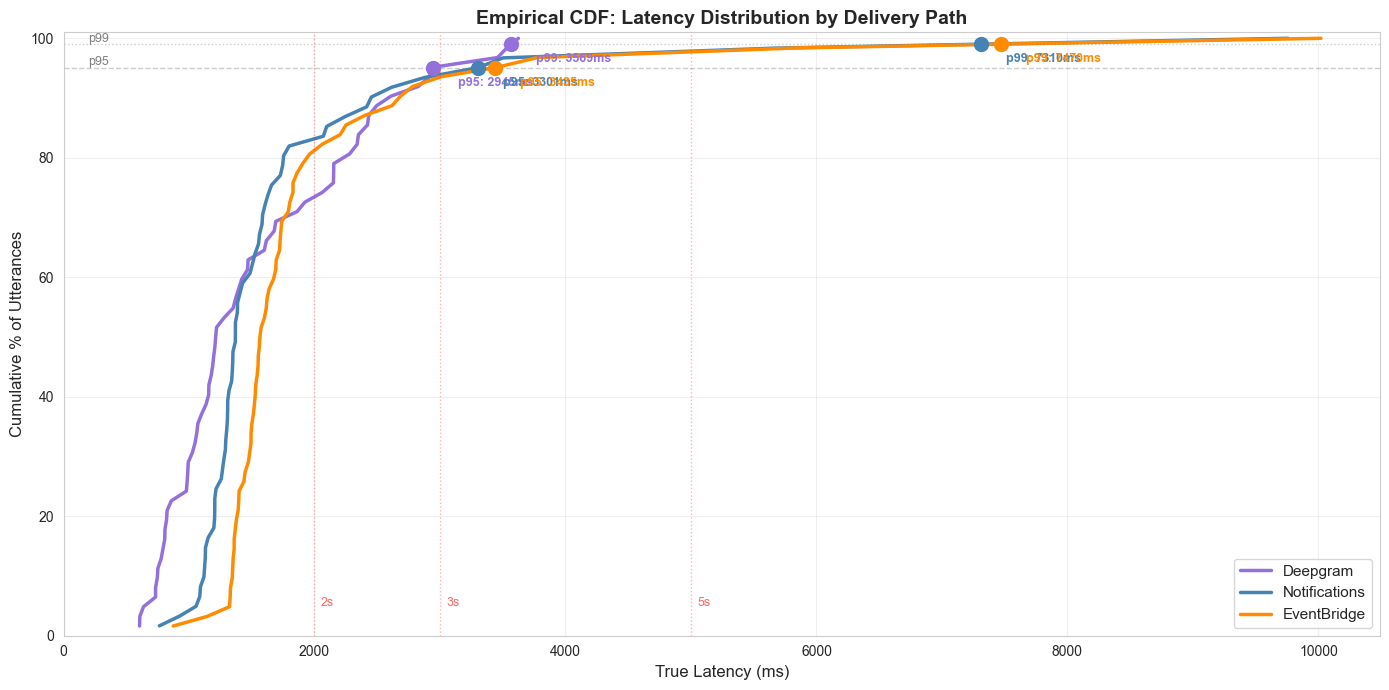

In [6]:
source_colors = {"Deepgram": "mediumpurple", "Notifications": "steelblue", "EventBridge": "darkorange"}

fig, ax = plt.subplots(figsize=(14, 7))

cdf_sources = [
    ("Deepgram", df_dg),
    ("Notifications", df_notif),
    ("EventBridge", df_eb),
]

for label, df in cdf_sources:
    if df.empty:
        continue
    vals = np.sort(df["true_latency_ms"].values)
    cdf = np.arange(1, len(vals) + 1) / len(vals) * 100
    ax.plot(vals, cdf, linewidth=2.5, color=source_colors[label], label=label)

    # Mark p95 and p99
    for pct, style in [(95, "--"), (99, ":")]:
        pval = np.percentile(vals, pct)
        ax.plot(pval, pct, "o", color=source_colors[label], markersize=10, zorder=5)
        ax.annotate(f"p{pct}: {pval:.0f}ms",
                    xy=(pval, pct), xytext=(pval + 200, pct - 3),
                    fontsize=9, fontweight="bold", color=source_colors[label])

# Horizontal reference lines
ax.axhline(95, color="gray", linestyle="--", alpha=0.4, linewidth=1)
ax.axhline(99, color="gray", linestyle=":", alpha=0.4, linewidth=1)
ax.text(200, 95.5, "p95", fontsize=9, color="gray")
ax.text(200, 99.3, "p99", fontsize=9, color="gray")

# Vertical SLA threshold lines
for t in [2000, 3000, 5000]:
    ax.axvline(t, color="red", linestyle=":", alpha=0.3, linewidth=1)
    ax.text(t + 50, 5, f"{t//1000}s", fontsize=9, color="red", alpha=0.6)

ax.set_xlabel("True Latency (ms)", fontsize=12)
ax.set_ylabel("Cumulative % of Utterances", fontsize=12)
ax.set_title("Empirical CDF: Latency Distribution by Delivery Path", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.set_xlim(0, None)
ax.set_ylim(0, 101)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cdf_overlay.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Module 7: Percentile Bar Chart

Grouped bars showing p50, p75, p90, p95, p99 side by side. Reveals how the inter-path gap changes at higher percentiles.

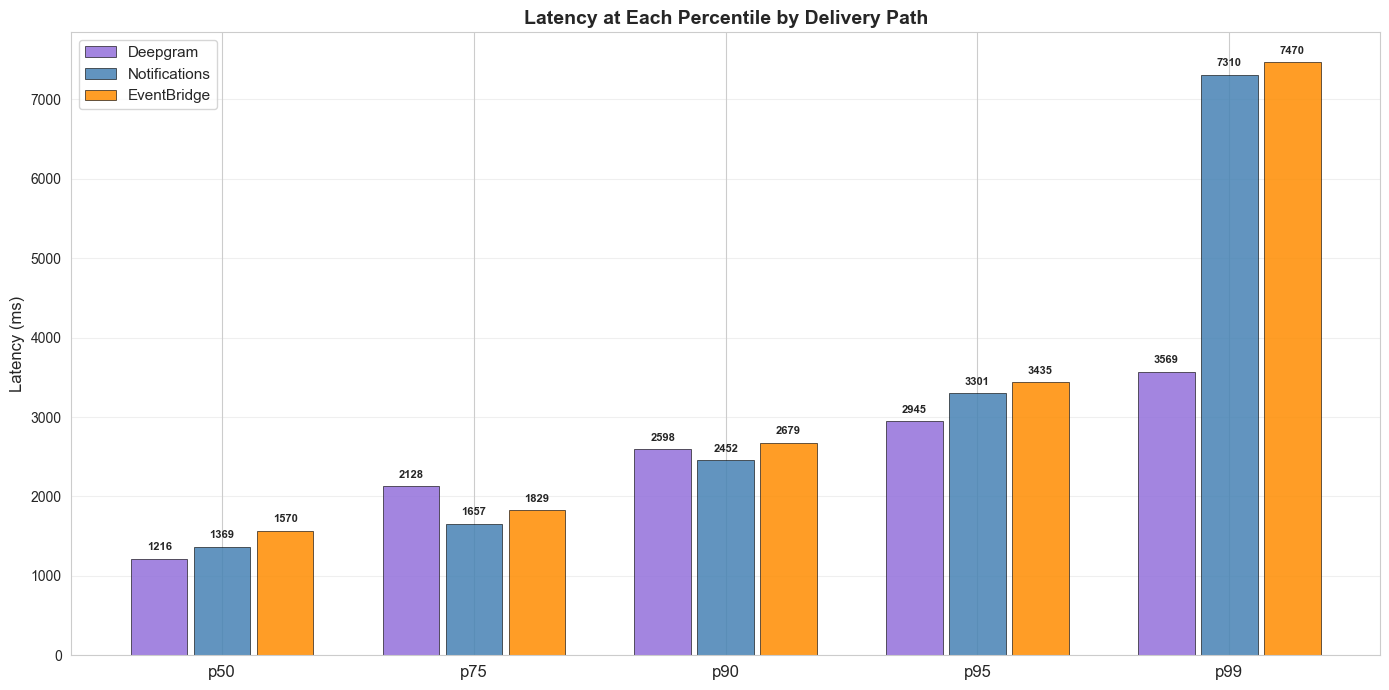

In [7]:
bar_sources = [
    ("Deepgram", dg_latencies_ms, "mediumpurple"),
    ("Notifications", df_notif["true_latency_ms"].tolist() if not df_notif.empty else [], "steelblue"),
    ("EventBridge", df_eb["true_latency_ms"].tolist() if not df_eb.empty else [], "darkorange"),
]
bar_sources = [(l, v, c) for l, v, c in bar_sources if v]

pct_labels = ["p50", "p75", "p90", "p95", "p99"]
pct_values = [0.50, 0.75, 0.90, 0.95, 0.99]
x = np.arange(len(pct_labels))
width = 0.25
offsets = np.linspace(-width, width, len(bar_sources))

fig, ax = plt.subplots(figsize=(14, 7))

for i, (label, vals, color) in enumerate(bar_sources):
    s = pd.Series(vals)
    heights = [s.quantile(p) for p in pct_values]
    bars = ax.bar(x + offsets[i], heights, width * 0.9, color=color, edgecolor="black",
                  linewidth=0.5, alpha=0.85, label=label)
    for bar, h in zip(bars, heights):
        ax.text(bar.get_x() + bar.get_width() / 2, h + 80, f"{h:.0f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(pct_labels, fontsize=12)
ax.set_ylabel("Latency (ms)", fontsize=12)
ax.set_title("Latency at Each Percentile by Delivery Path", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "percentile_bars.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Module 8: SLA Violation Rates

What fraction of utterances exceed operational thresholds? At 800,000 utterances/day, even small percentages translate to large absolute counts.

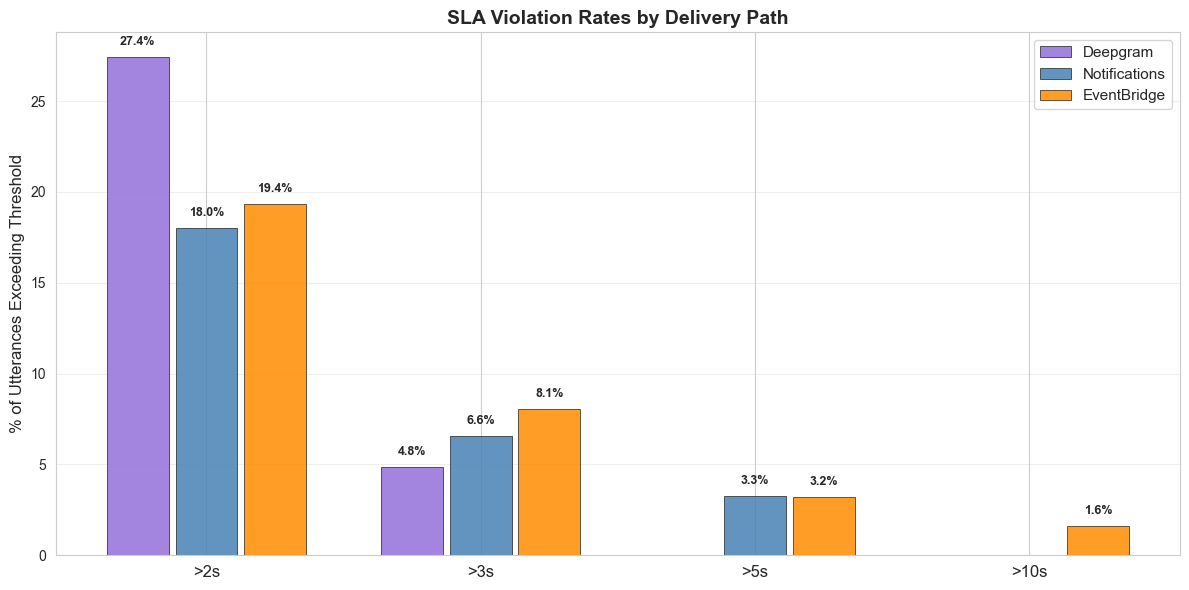

In [8]:
sla_bar_sources = [
    ("Deepgram", dg_latencies_ms, "mediumpurple"),
    ("Notifications", df_notif["true_latency_ms"].tolist() if not df_notif.empty else [], "steelblue"),
    ("EventBridge", df_eb["true_latency_ms"].tolist() if not df_eb.empty else [], "darkorange"),
]
sla_bar_sources = [(l, v, c) for l, v, c in sla_bar_sources if v]
thresholds = [2000, 3000, 5000, 10000]
thresh_labels = [">2s", ">3s", ">5s", ">10s"]

x = np.arange(len(thresh_labels))
width = 0.25
offsets = np.linspace(-width, width, len(sla_bar_sources))

fig, ax = plt.subplots(figsize=(12, 6))

for i, (label, vals, color) in enumerate(sla_bar_sources):
    exc = sla_exceedance(vals, thresholds)
    heights = [exc[t] for t in thresholds]
    bars = ax.bar(x + offsets[i], heights, width * 0.9, color=color, edgecolor="black",
                  linewidth=0.5, alpha=0.85, label=label)
    for bar, h in zip(bars, heights):
        if h > 0.5:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f"{h:.1f}%",
                    ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(thresh_labels, fontsize=12)
ax.set_ylabel("% of Utterances Exceeding Threshold", fontsize=12)
ax.set_title("SLA Violation Rates by Delivery Path", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sla_violation_rates.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Module 9: Tail Latency Deep Dive

Scatter plot of p90+ utterances only. Are tail events clustered in specific conversations, or spread uniformly?

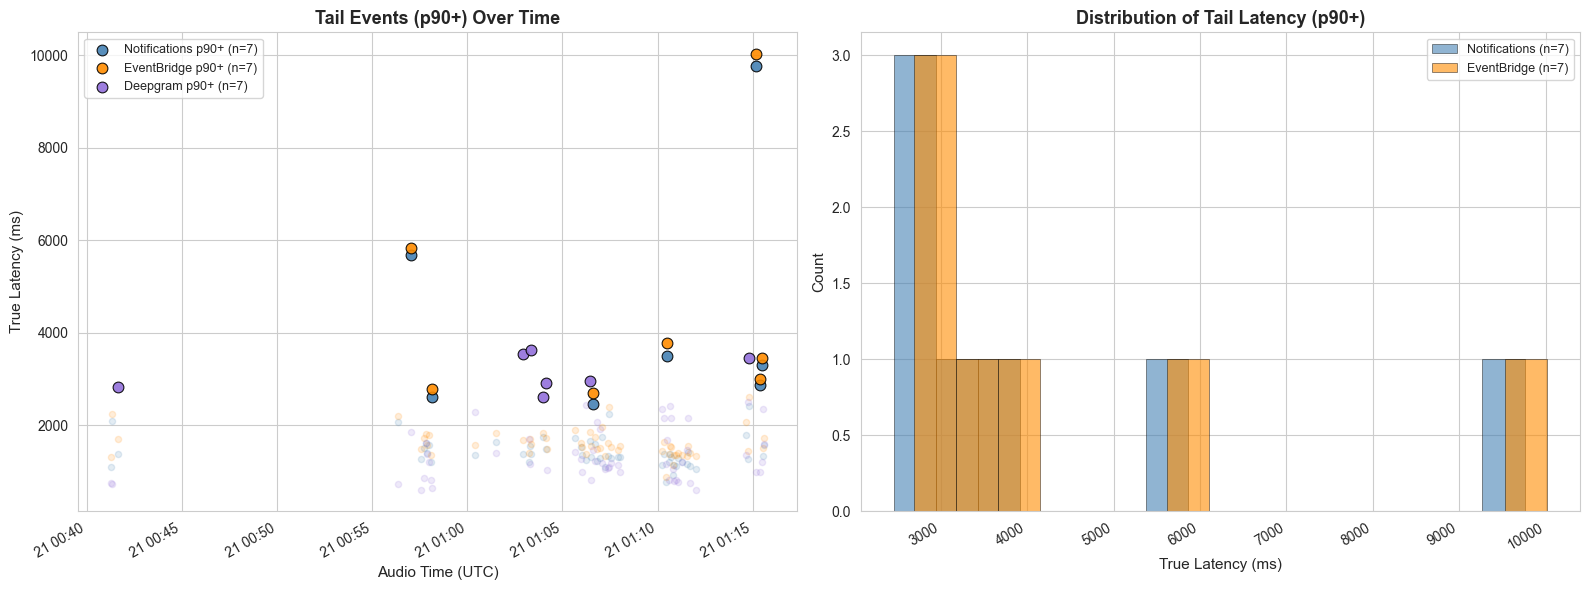


TAIL EVENTS (p90+) PER CONVERSATION

Notifications: 7 tail events out of 61 total (11%)
  00:57:02 — 5679ms — "practical how do you drink with such a nose you mu"
  00:58:10 — 2615ms — "these my dear sod are things you might have said h"
  01:06:37 — 2452ms — "an assumption of one of associates with modems of "
  01:10:29 — 3503ms — "what i mean you're ready to rejoin so"
  01:15:09 — 9757ms — "it is one thing question the official story and an"
  01:15:24 — 2878ms — "fantastic i'm just not the hero type clearly with "
  01:15:28 — 3301ms — "laundry listed character defects all the mistakes "

EventBridge: 7 tail events out of 62 total (11%)
  00:57:02 — 5839ms — "practical how do you drink with such a nose you mu"
  00:58:10 — 2782ms — "these my dear sod are things you might have said h"
  01:06:37 — 2686ms — "an assumption of one of associates with modems of "
  01:10:29 — 3776ms — "what i mean you're ready to rejoin so"
  01:15:09 — 10020ms — "it is one thing question the official 

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Scatter of p90+ events over time
ax = axes[0]
for label, df, color in [("Notifications", df_notif, "steelblue"), ("EventBridge", df_eb, "darkorange"), ("Deepgram", df_dg, "mediumpurple")]:
    if df.empty:
        continue
    p90 = df["true_latency_ms"].quantile(0.90)
    tail = df[df["true_latency_ms"] >= p90]
    body = df[df["true_latency_ms"] < p90]
    ax.scatter(body["audio_dt"], body["true_latency_ms"], alpha=0.15, s=20, color=color)
    ax.scatter(tail["audio_dt"], tail["true_latency_ms"], alpha=0.9, s=60, color=color,
               edgecolors="black", linewidth=0.8, label=f"{label} p90+ (n={len(tail)})")

ax.set_xlabel("Audio Time (UTC)", fontsize=11)
ax.set_ylabel("True Latency (ms)", fontsize=11)
ax.set_title("Tail Events (p90+) Over Time", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
fig.autofmt_xdate()

# Right: Distribution of tail events — are they in the same conversations?
ax = axes[1]
tail_sources = []
for label, df, color in [("Notifications", df_notif, "steelblue"), ("EventBridge", df_eb, "darkorange")]:
    if df.empty:
        continue
    p90 = df["true_latency_ms"].quantile(0.90)
    tail = df[df["true_latency_ms"] >= p90]
    tail_sources.append((label, tail["true_latency_ms"].values, color))

if tail_sources:
    for label, vals, color in tail_sources:
        ax.hist(vals, bins=15, alpha=0.6, color=color, edgecolor="black",
                linewidth=0.5, label=f"{label} (n={len(vals)})")

ax.set_xlabel("True Latency (ms)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Distribution of Tail Latency (p90+)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tail_latency_deep_dive.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

# Print tail event counts per conversation
print("\nTAIL EVENTS (p90+) PER CONVERSATION")
print("=" * 60)
for label, df in [("Notifications", df_notif), ("EventBridge", df_eb)]:
    if df.empty:
        continue
    p90 = df["true_latency_ms"].quantile(0.90)
    tail = df[df["true_latency_ms"] >= p90]
    total = len(df)
    print(f"\n{label}: {len(tail)} tail events out of {total} total ({len(tail)/total*100:.0f}%)")
    # Group by rough conversation window (5-min bins)
    if not tail.empty:
        tail_sorted = tail.sort_values("audio_dt")
        for _, row in tail_sorted.iterrows():
            print(f"  {row['audio_dt'].strftime('%H:%M:%S')} — {row['true_latency_ms']:.0f}ms — \"{row['genesys_transcript'][:50]}\"")

---
## Module 10: EventBridge Hop Analysis at Percentiles

Same 2-hop decomposition, but showing p50 through p99 instead of mean/median.

EVENTBRIDGE 2-HOP ANALYSIS — PERCENTILE BREAKDOWN
Hop                                           p50      p75      p90      p95      p99     N
----------------------------------------------------------------------------------------------------
Hop A: Genesys -> SQS enqueue                169ms     192ms     212ms     226ms     251ms   145
Hop B: SQS -> Consumer poll                   56ms      80ms     135ms     142ms     165ms   145
Total: Genesys -> Consumer                   238ms     276ms     312ms     325ms     343ms   145


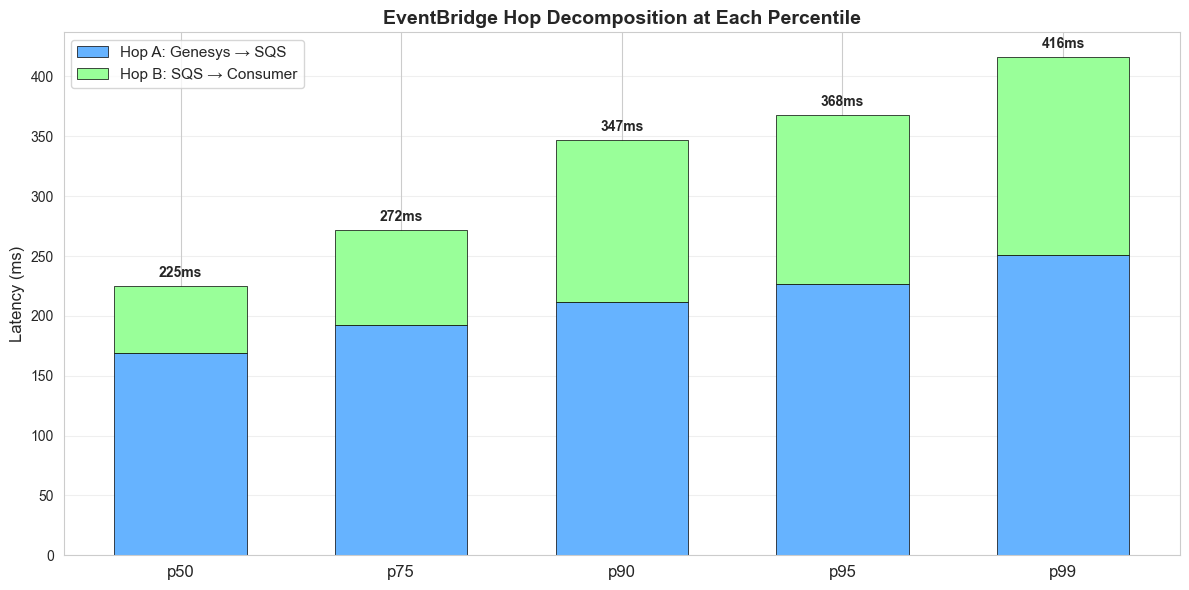

In [10]:
if not df_hops.empty:
    print("EVENTBRIDGE 2-HOP ANALYSIS — PERCENTILE BREAKDOWN")
    print("=" * 100)
    header = f"{'Hop':<40} {'p50':>8} {'p75':>8} {'p90':>8} {'p95':>8} {'p99':>8} {'N':>5}"
    print(header)
    print("-" * 100)

    hop_labels = {
        "hopA_ms": "Hop A: Genesys -> SQS enqueue",
        "hopB_ms": "Hop B: SQS -> Consumer poll",
        "total_ms": "Total: Genesys -> Consumer",
    }

    for col, label in hop_labels.items():
        vals = df_hops[col]
        line = f"{label:<40}"
        for p in PERCENTILES:
            line += f" {vals.quantile(p):>7.0f}ms"
        line += f" {len(vals):>5}"
        print(line)

    # Percentile stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 6))
    pct_labels_hop = ["p50", "p75", "p90", "p95", "p99"]
    hopA_vals = [df_hops["hopA_ms"].quantile(p) for p in pct_values]
    hopB_vals = [df_hops["hopB_ms"].quantile(p) for p in pct_values]

    x = np.arange(len(pct_labels_hop))
    ax.bar(x, hopA_vals, 0.6, color="#66b3ff", edgecolor="black", linewidth=0.5,
           label="Hop A: Genesys → SQS")
    ax.bar(x, hopB_vals, 0.6, bottom=hopA_vals, color="#99ff99", edgecolor="black",
           linewidth=0.5, label="Hop B: SQS → Consumer")

    for i, (a, b) in enumerate(zip(hopA_vals, hopB_vals)):
        ax.text(i, a + b + 5, f"{a + b:.0f}ms", ha="center", va="bottom",
                fontsize=10, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(pct_labels_hop, fontsize=12)
    ax.set_ylabel("Latency (ms)", fontsize=12)
    ax.set_title("EventBridge Hop Decomposition at Each Percentile", fontsize=14, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hop_percentiles.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()
else:
    print("No EventBridge hop data available.")

---
## Module 11: Self-Reported vs True Latency at Each Percentile

The self-reported/true ratio changes at higher percentiles. This module quantifies exactly how much the understatement grows at the tail.

SELF-REPORTED vs TRUE LATENCY — PERCENTILE COMPARISON

Notifications:
  Percentile         True   Self-Rep    Ratio        Gap
  -------------------------------------------------------
  p50              1369ms       346ms     4.0x     +1024ms
  p75              1657ms       568ms     2.9x     +1089ms
  p90              2452ms      1010ms     2.4x     +1442ms
  p95              3301ms      1192ms     2.8x     +2109ms
  p99              7310ms      2097ms     3.5x     +5214ms

EventBridge:
  Percentile         True   Self-Rep    Ratio        Gap
  -------------------------------------------------------
  p50              1570ms       356ms     4.4x     +1214ms
  p75              1829ms       594ms     3.1x     +1234ms
  p90              2679ms      1071ms     2.5x     +1608ms
  p95              3435ms      1236ms     2.8x     +2198ms
  p99              7470ms      2781ms     2.7x     +4689ms


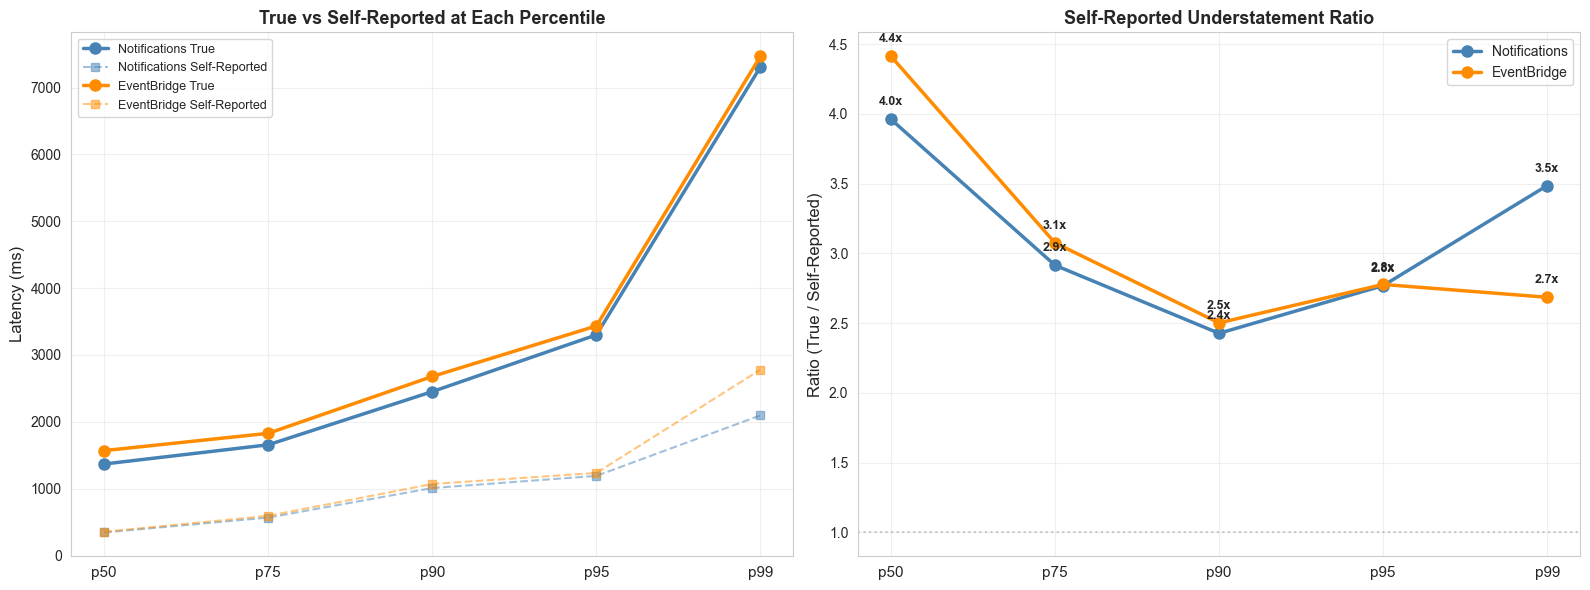

In [11]:
print("SELF-REPORTED vs TRUE LATENCY — PERCENTILE COMPARISON")
print("=" * 110)

comparison_pairs = []
if not df_notif.empty and sr_latencies_ms:
    comparison_pairs.append(("Notifications", df_notif["true_latency_ms"], pd.Series(sr_latencies_ms)))
if not df_eb.empty and eb_sr_latencies_ms:
    comparison_pairs.append(("EventBridge", df_eb["true_latency_ms"], pd.Series(eb_sr_latencies_ms)))

for label, true_s, sr_s in comparison_pairs:
    print(f"\n{label}:")
    header = f"  {'Percentile':<12} {'True':>10} {'Self-Rep':>10} {'Ratio':>8} {'Gap':>10}"
    print(header)
    print(f"  {'-' * 55}")
    for p in PERCENTILES:
        true_val = true_s.quantile(p)
        sr_val = sr_s.quantile(p)
        ratio = true_val / sr_val if sr_val > 0 else float("inf")
        gap = true_val - sr_val
        print(f"  p{int(p*100):<10} {true_val:>9.0f}ms {sr_val:>9.0f}ms {ratio:>7.1f}x {gap:>+9.0f}ms")

# Visualization: ratio at each percentile
if comparison_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = {"Notifications": "steelblue", "EventBridge": "darkorange"}

    # Left: Absolute comparison
    ax = axes[0]
    x = np.arange(len(PERCENTILES))
    for label, true_s, sr_s in comparison_pairs:
        true_vals = [true_s.quantile(p) for p in PERCENTILES]
        sr_vals = [sr_s.quantile(p) for p in PERCENTILES]
        ax.plot(x, true_vals, "o-", color=colors[label], linewidth=2.5, markersize=8,
                label=f"{label} True")
        ax.plot(x, sr_vals, "s--", color=colors[label], linewidth=1.5, markersize=6,
                alpha=0.5, label=f"{label} Self-Reported")

    ax.set_xticks(x)
    ax.set_xticklabels([f"p{int(p*100)}" for p in PERCENTILES], fontsize=11)
    ax.set_ylabel("Latency (ms)", fontsize=12)
    ax.set_title("True vs Self-Reported at Each Percentile", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Right: Ratio (true / self-reported)
    ax = axes[1]
    for label, true_s, sr_s in comparison_pairs:
        ratios = []
        for p in PERCENTILES:
            true_val = true_s.quantile(p)
            sr_val = sr_s.quantile(p)
            ratios.append(true_val / sr_val if sr_val > 0 else 0)
        ax.plot(x, ratios, "o-", color=colors[label], linewidth=2.5, markersize=8, label=label)
        for i, r in enumerate(ratios):
            ax.annotate(f"{r:.1f}x", xy=(i, r), xytext=(0, 10),
                        textcoords="offset points", ha="center", fontsize=9, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels([f"p{int(p*100)}" for p in PERCENTILES], fontsize=11)
    ax.set_ylabel("Ratio (True / Self-Reported)", fontsize=12)
    ax.set_title("Self-Reported Understatement Ratio", fontsize=13, fontweight="bold")
    ax.axhline(1.0, color="gray", linestyle=":", alpha=0.4)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "self_reported_vs_true_percentiles.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

---
## Module 12: Confidence at the Tail

Do high-latency utterances (p90+) have different confidence scores than the body (<p90)? If so, confidence may be a proxy for predicting slow delivery.

CONFIDENCE AT TAIL vs BODY

Notifications (split at p90 = 2452ms):
  Metric                     Body (<p90)   Tail (>=p90)      Delta
  -----------------------------------------------------------------
  Deepgram median                  97.8%          99.3%      +1.5%
  Genesys/r2d2 median              79.4%          83.7%      +4.3%
  N                                   54              7

EventBridge (split at p90 = 2679ms):
  Metric                     Body (<p90)   Tail (>=p90)      Delta
  -----------------------------------------------------------------
  Deepgram median                  97.7%          99.3%      +1.6%
  Genesys/r2d2 median              80.2%          83.7%      +3.5%
  N                                   55              7


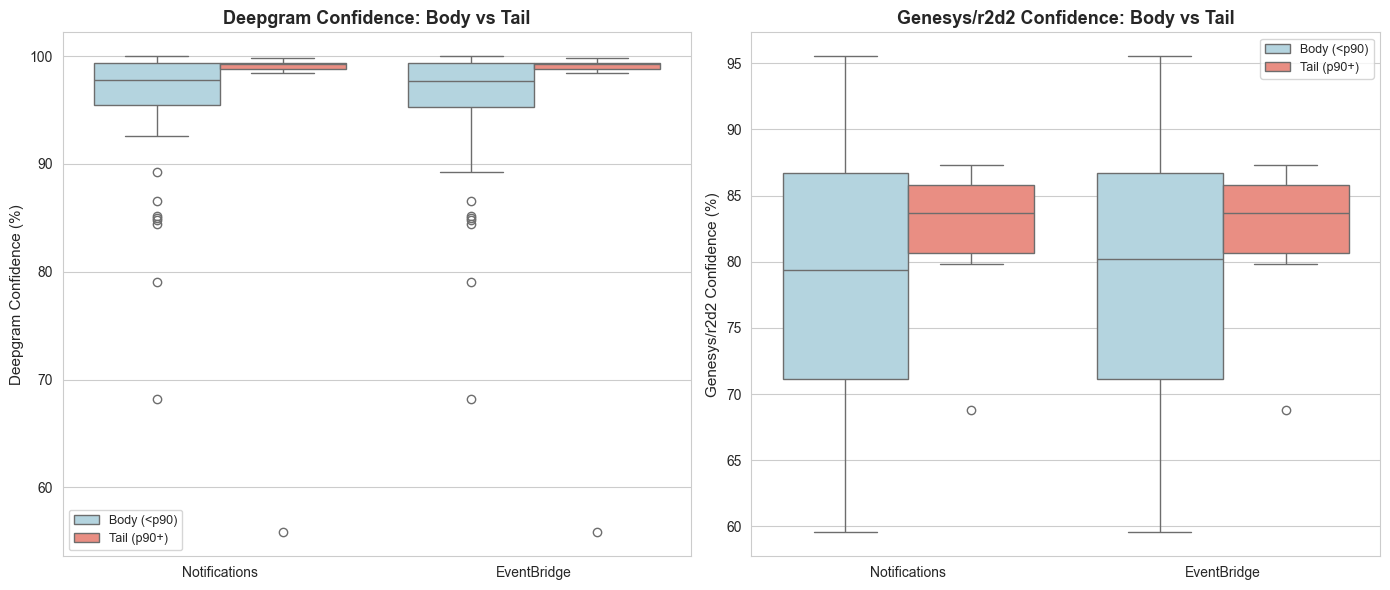

In [12]:
print("CONFIDENCE AT TAIL vs BODY")
print("=" * 80)

for label, df in [("Notifications", df_notif), ("EventBridge", df_eb)]:
    if df.empty or "deepgram_confidence" not in df.columns:
        continue
    p90 = df["true_latency_ms"].quantile(0.90)
    body = df[df["true_latency_ms"] < p90]
    tail = df[df["true_latency_ms"] >= p90]

    print(f"\n{label} (split at p90 = {p90:.0f}ms):")
    print(f"  {'Metric':<25} {'Body (<p90)':>12} {'Tail (>=p90)':>14} {'Delta':>10}")
    print(f"  {'-' * 65}")

    for conf_col, eng in [("deepgram_confidence", "Deepgram"), ("genesys_confidence", "Genesys/r2d2")]:
        body_med = body[conf_col].median() * 100
        tail_med = tail[conf_col].median() * 100
        delta = tail_med - body_med
        print(f"  {eng + ' median':<25} {body_med:>11.1f}% {tail_med:>13.1f}% {delta:>+9.1f}%")

    print(f"  {'N':<25} {len(body):>12} {len(tail):>14}")

# Visualization: violin/box plots split by body vs tail
plot_dfs = []
for label, df in [("Notifications", df_notif), ("EventBridge", df_eb)]:
    if df.empty:
        continue
    p90 = df["true_latency_ms"].quantile(0.90)
    temp = df[["true_latency_ms", "deepgram_confidence", "genesys_confidence"]].copy()
    temp["region"] = np.where(temp["true_latency_ms"] >= p90, "Tail (p90+)", "Body (<p90)")
    temp["source"] = label
    plot_dfs.append(temp)

if plot_dfs:
    df_conf_split = pd.concat(plot_dfs, ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for i, (conf_col, eng) in enumerate([("deepgram_confidence", "Deepgram"), ("genesys_confidence", "Genesys/r2d2")]):
        ax = axes[i]
        df_plot = df_conf_split.copy()
        df_plot[conf_col] = df_plot[conf_col] * 100

        sns.boxplot(data=df_plot, x="source", y=conf_col, hue="region", ax=ax,
                    palette={"Body (<p90)": "lightblue", "Tail (p90+)": "salmon"})
        ax.set_ylabel(f"{eng} Confidence (%)", fontsize=11)
        ax.set_xlabel("")
        ax.set_title(f"{eng} Confidence: Body vs Tail", fontsize=13, fontweight="bold")
        ax.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "confidence_body_vs_tail.png", dpi=SAVE_DPI, bbox_inches="tight")
    plt.show()

---
## Module 13: Export Results

In [13]:
def compute_full_stats(values_ms):
    """Compute full stats including all percentiles."""
    if not values_ms:
        return {}
    s = pd.Series(values_ms)
    result = {
        "n": len(s),
        "mean": float(s.mean()),
        "std": float(s.std()),
        "min": float(s.min()),
        "max": float(s.max()),
    }
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        result[f"p{int(p*100)}"] = float(s.quantile(p))
    return result


# Export CSVs
if notif_results:
    export_csv(notif_results, OUTPUT_DIR / "notif_correlation.csv")
if eb_results:
    export_csv(eb_results, OUTPUT_DIR / "eb_correlation.csv")

# Export percentile-focused comparison JSON
comparison = {
    "focus": "p95_p99_percentile_analysis",
    "session_triples": [
        {"deepgram": dg.name, "notifications": nf.name, "eventbridge": eb.name if eb else None}
        for dg, nf, eb in triple_matched
    ],
    "similarity_threshold": SIMILARITY_THRESHOLD,
    "latency": {
        "deepgram": compute_full_stats(dg_latencies_ms),
        "notifications": compute_full_stats(df_notif["true_latency_ms"].tolist()) if not df_notif.empty else {},
        "eventbridge": compute_full_stats(df_eb["true_latency_ms"].tolist()) if not df_eb.empty else {},
        "notif_self_reported": compute_full_stats(sr_latencies_ms),
        "eb_self_reported": compute_full_stats(eb_sr_latencies_ms),
    },
    "sla_exceedance_pct": {},
}

for label, vals in [("deepgram", dg_latencies_ms),
                     ("notifications", df_notif["true_latency_ms"].tolist() if not df_notif.empty else []),
                     ("eventbridge", df_eb["true_latency_ms"].tolist() if not df_eb.empty else [])]:
    if vals:
        comparison["sla_exceedance_pct"][label] = {f">{t//1000}s": round(sla_exceedance(vals, [t])[t], 2) for t in SLA_THRESHOLDS_MS}

# Hop analysis at percentiles
if not df_hops.empty:
    comparison["hop_analysis_percentiles"] = {}
    for col, label in [("hopA_ms", "hopA_genesys_to_sqs"), ("hopB_ms", "hopB_sqs_to_consumer"), ("total_ms", "total")]:
        comparison["hop_analysis_percentiles"][label] = compute_full_stats(df_hops[col].tolist())

# Confidence
conf_export = {}
for label, df_src in [("notifications", df_notif), ("eventbridge", df_eb)]:
    if not df_src.empty and "deepgram_confidence" in df_src.columns:
        conf_export[label] = {
            "deepgram": {
                "median": float(df_src["deepgram_confidence"].median()),
                "mean": float(df_src["deepgram_confidence"].mean()),
                "min": float(df_src["deepgram_confidence"].min()),
                "max": float(df_src["deepgram_confidence"].max()),
                "n": len(df_src),
            },
            "genesys_r2d2": {
                "median": float(df_src["genesys_confidence"].median()),
                "mean": float(df_src["genesys_confidence"].mean()),
                "min": float(df_src["genesys_confidence"].min()),
                "max": float(df_src["genesys_confidence"].max()),
                "n": len(df_src),
            },
        }
if conf_export:
    comparison["confidence"] = conf_export

(OUTPUT_DIR / "p99_comparison.json").write_text(json.dumps(comparison, indent=2))

print(f"Exported to {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}")

Exported to /Users/xnxn040/PycharmProjects/notifications-spike/analysis_results/cross_system_eb_p99:
  cdf_overlay.png
  confidence_body_vs_tail.png
  eb_correlation.csv
  hop_percentiles.png
  notif_correlation.csv
  p99_comparison.json
  percentile_bars.png
  self_reported_vs_true_percentiles.png
  sla_violation_rates.png
  tail_latency_deep_dive.png
